In [16]:
import pandas as pd
from tensorflow import keras
import tensorflow as tf
import numpy as np
import os

from datetime import datetime
from sklearn.preprocessing import MinMaxScaler

from keras.optimizers import Adam
from sklearn.metrics import classification_report, accuracy_score
from tensorflow.keras import callbacks



In [17]:
os.environ['TF_CPP_MIN_LOG_LEVEL']='2' #remove log error

In [18]:
df=pd.read_csv("cleaned_dataset_taiwan_2months.csv") #read the dataset

df = df.dropna(subset=['status'])
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125914 entries, 0 to 125913
Data columns (total 14 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   date      125914 non-null  object 
 1   sitename  125914 non-null  object 
 2   county    125914 non-null  object 
 3   aqi       125914 non-null  float64
 4   status    125914 non-null  object 
 5   so2       125914 non-null  float64
 6   co        125914 non-null  float64
 7   o3        125914 non-null  float64
 8   pm10      125914 non-null  float64
 9   pm2.5     125914 non-null  float64
 10  no2       125914 non-null  float64
 11  nox       125914 non-null  float64
 12  no        125914 non-null  float64
 13  siteid    125914 non-null  int64  
dtypes: float64(9), int64(1), object(4)
memory usage: 13.4+ MB


In [19]:
#convert the column from string to numeric number
to_numeric_column=["aqi",'so2','co','o3','pm2.5','pm10','no2','nox','no','siteid'] 
df[to_numeric_column]=df[to_numeric_column].apply(pd.to_numeric, errors='coerce')
df[to_numeric_column] = df[to_numeric_column].ffill().bfill() #make all gaps null value
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125914 entries, 0 to 125913
Data columns (total 14 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   date      125914 non-null  object 
 1   sitename  125914 non-null  object 
 2   county    125914 non-null  object 
 3   aqi       125914 non-null  float64
 4   status    125914 non-null  object 
 5   so2       125914 non-null  float64
 6   co        125914 non-null  float64
 7   o3        125914 non-null  float64
 8   pm10      125914 non-null  float64
 9   pm2.5     125914 non-null  float64
 10  no2       125914 non-null  float64
 11  nox       125914 non-null  float64
 12  no        125914 non-null  float64
 13  siteid    125914 non-null  int64  
dtypes: float64(9), int64(1), object(4)
memory usage: 13.4+ MB


In [20]:
df.head()

,date,sitename,county,aqi,status,so2,co,o3,pm10,pm2.5,no2,nox,no,siteid
0,2024-08-31 23:00:00,Hukou,Hsinchu County,62.0,Moderate,0.9,0.17,35.0,18.0,17.0,2.3,2.6,0.3,22
1,2024-08-31 23:00:00,Zhongming,Taichung City,50.0,Good,1.6,0.32,27.9,27.0,14.0,7.6,9.3,1.6,31
2,2024-08-31 23:00:00,Zhudong,Hsinchu County,45.0,Good,0.4,0.17,25.1,21.0,13.0,2.9,4.1,1.1,23
3,2024-08-31 23:00:00,Hsinchu,Hsinchu City,42.0,Good,0.8,0.20,30.0,19.0,10.0,4.0,4.8,0.7,24
4,2024-08-31 23:00:00,Toufen,Miaoli County,50.0,Good,1.0,0.16,33.5,18.0,14.0,1.8,3.1,1.2,25


In [21]:
df['date']=pd.to_datetime(df['date']) #datetime format
df.head()

,date,sitename,county,aqi,status,so2,co,o3,pm10,pm2.5,no2,nox,no,siteid
0,2024-08-31 23:00:00,Hukou,Hsinchu County,62.0,Moderate,0.9,0.17,35.0,18.0,17.0,2.3,2.6,0.3,22
1,2024-08-31 23:00:00,Zhongming,Taichung City,50.0,Good,1.6,0.32,27.9,27.0,14.0,7.6,9.3,1.6,31
2,2024-08-31 23:00:00,Zhudong,Hsinchu County,45.0,Good,0.4,0.17,25.1,21.0,13.0,2.9,4.1,1.1,23
3,2024-08-31 23:00:00,Hsinchu,Hsinchu City,42.0,Good,0.8,0.20,30.0,19.0,10.0,4.0,4.8,0.7,24
4,2024-08-31 23:00:00,Toufen,Miaoli County,50.0,Good,1.0,0.16,33.5,18.0,14.0,1.8,3.1,1.2,25


In [22]:
df.head()

,date,sitename,county,aqi,status,so2,co,o3,pm10,pm2.5,no2,nox,no,siteid
0,2024-08-31 23:00:00,Hukou,Hsinchu County,62.0,Moderate,0.9,0.17,35.0,18.0,17.0,2.3,2.6,0.3,22
1,2024-08-31 23:00:00,Zhongming,Taichung City,50.0,Good,1.6,0.32,27.9,27.0,14.0,7.6,9.3,1.6,31
2,2024-08-31 23:00:00,Zhudong,Hsinchu County,45.0,Good,0.4,0.17,25.1,21.0,13.0,2.9,4.1,1.1,23
3,2024-08-31 23:00:00,Hsinchu,Hsinchu City,42.0,Good,0.8,0.20,30.0,19.0,10.0,4.0,4.8,0.7,24
4,2024-08-31 23:00:00,Toufen,Miaoli County,50.0,Good,1.0,0.16,33.5,18.0,14.0,1.8,3.1,1.2,25


In [23]:
def model_train(input_shape):
    model=keras.models.Sequential()

    model.add(keras.layers.Input(shape=input_shape))

   # model.add(keras.layers.LSTM(254,return_sequences=True))
    #model.add(keras.layers.Dropout(0.5))

    model.add(keras.layers.LSTM(128,return_sequences=True))
    model.add(keras.layers.Dropout(0.4))
    
    model.add(keras.layers.LSTM(64,return_sequences=False))
    model.add(keras.layers.Dropout(0.3))

    
    model.add(keras.layers.Dense(32,activation="relu"))
    model.add(keras.layers.Dense(1))
    

    return model

#model layers for training

In [24]:
n_windows=100 #number of look back in the dataset
scaler=MinMaxScaler(feature_range=(0,1))


#scale column for training
feature_cols=['aqi','so2','co','o3','pm2.5','pm10','no2','nox','no']
df[feature_cols] = scaler.fit_transform(df[feature_cols])


In [25]:




X_train,y_train=[],[]
X_test_all, y_test_all = [], []



for station, group in df.groupby('sitename'):
    # timline sorted chronologically
    group = group.sort_values('date')
    station_data = group[feature_cols].values
    
    # train test split (80/20 split)
    train_len = int(np.ceil(len(station_data) * 0.80))
    
    # training windodw
    for i in range(n_windows, train_len):
        X_train.append(station_data[i-n_windows:i])
        y_train.append(station_data[i, 0]) # index 0 is aqi
        
    # tersting window
    for i in range(train_len, len(station_data)):
        X_test_all.append(station_data[i-n_windows:i])  
        y_test_all.append(station_data[i, 0])

X_train, y_train = np.array(X_train), np.array(y_train)
X_test_all, y_test_all = np.array(X_test_all), np.array(y_test_all)
model = model_train(input_shape=(X_train.shape[1], X_train.shape[2]))

In [26]:
print(X_train.shape)

(92280, 100, 9)


In [ ]:
reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.2, 
    patience=3, 
    min_lr=1e-6
)
#call back and checkpoint

my_callbacks = [
    callbacks.EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True),
    callbacks.ModelCheckpoint(filepath='tuned_best_model_lstm_regressor.keras', monitor='val_loss', save_best_only=True),
    reduce_lr
]

In [ ]:
model.compile(
            optimizer=Adam(learning_rate=0.0005),
            loss="mae",  #mae
            metrics=[
 "mae","mse"
    ])
#model training
model.fit(X_train, y_train, epochs=50, batch_size=128, shuffle=True,verbose=1,callbacks=my_callbacks,validation_split=0.2)

Epoch 1/50
 42/577 ━━━━━━━━━━━━━━━━━━━━ 1:41 189ms/step - loss: 0.1001 - mae: 0.1001 - mse: 0.0174

KeyboardInterrupt: 

In [32]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
best_model=tf.keras.models.load_model("best_model_lstm_regressor.keras")


X_test_all = np.array(X_test_all)
y_test_all = np.array(y_test_all)

# 2. Generate Predictions
predictions_scaled = best_model.predict(X_test_all, verbose=1)

# 3. Inverse Scale the Predictions
dummy = np.zeros((len(predictions_scaled), 9))
dummy[:, 0] = predictions_scaled.flatten()
predictions_all = scaler.inverse_transform(dummy)[:, 0]

dummy_true = np.zeros((len(y_test_all), 9))
dummy_true[:, 0] = y_test_all
y_test_all = scaler.inverse_transform(dummy_true)[:, 0]

# 4. Calculate Final Global Metrics
global_mae = mean_absolute_error(y_test_all, predictions_all)
global_rmse = np.sqrt(mean_squared_error(y_test_all, predictions_all))
global_mse = mean_squared_error(y_test_all, predictions_all)
global_r2 = r2_score(y_test_all, predictions_all)

print("--- Overall Model Performance (Test Set) ---")
print(f"Global R-squared (R2): {global_r2:.4f}")

print(f"Global Mean Absolute Error (MAE): {global_mae:.2f} AQI points")
print(f"Global Root Mean Squared Error (RMSE): {global_rmse:.2f} AQI points")
print(f"Global Mean Squared Error (MSE): {global_mse:.2f} AQI points")



786/786 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step
--- Overall Model Performance (Test Set) ---
Global R-squared (R2): 0.9739
Global Mean Absolute Error (MAE): 1.50 AQI points
Global Root Mean Squared Error (RMSE): 2.47 AQI points
Global Mean Squared Error (MSE): 6.11 AQI points


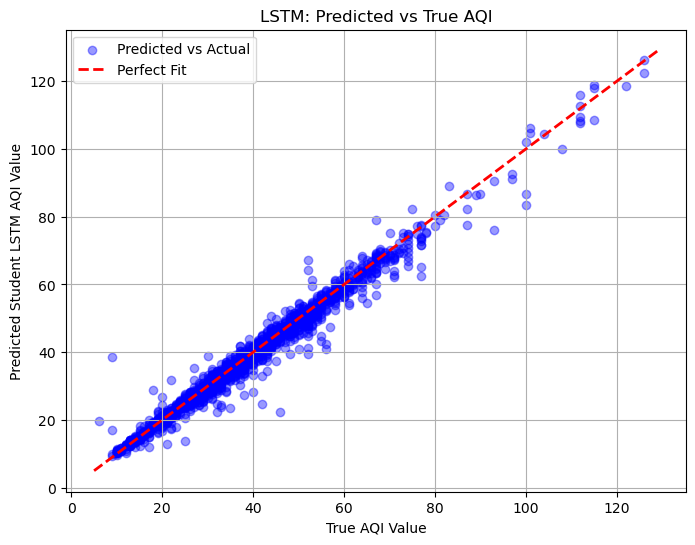

In [33]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
plt.scatter(y_test_all[:2000], predictions_all[:2000], alpha=0.4, color='b', label='Predicted vs Actual')

# Plot accurate perfect diagonal trendline boundary
perfect_line = [min(y_test_all), max(y_test_all)]
plt.plot(perfect_line, perfect_line, color='red', linestyle='--', linewidth=2, label='Perfect Fit')

plt.xlabel('True AQI Value')
plt.ylabel('Predicted Student LSTM AQI Value')
plt.title('LSTM: Predicted vs True AQI')
plt.legend()
plt.grid(True)
plt.savefig('LSTM_fit.png')

--- Classification Report ---
                                precision    recall  f1-score   support

                          Good       0.98      0.98      0.98     20129
                      Moderate       0.92      0.91      0.92      4945
Unhealthy for Sensitive Groups       0.89      0.82      0.85        60

                      accuracy                           0.97     25134
                     macro avg       0.93      0.90      0.92     25134
                  weighted avg       0.97      0.97      0.97     25134



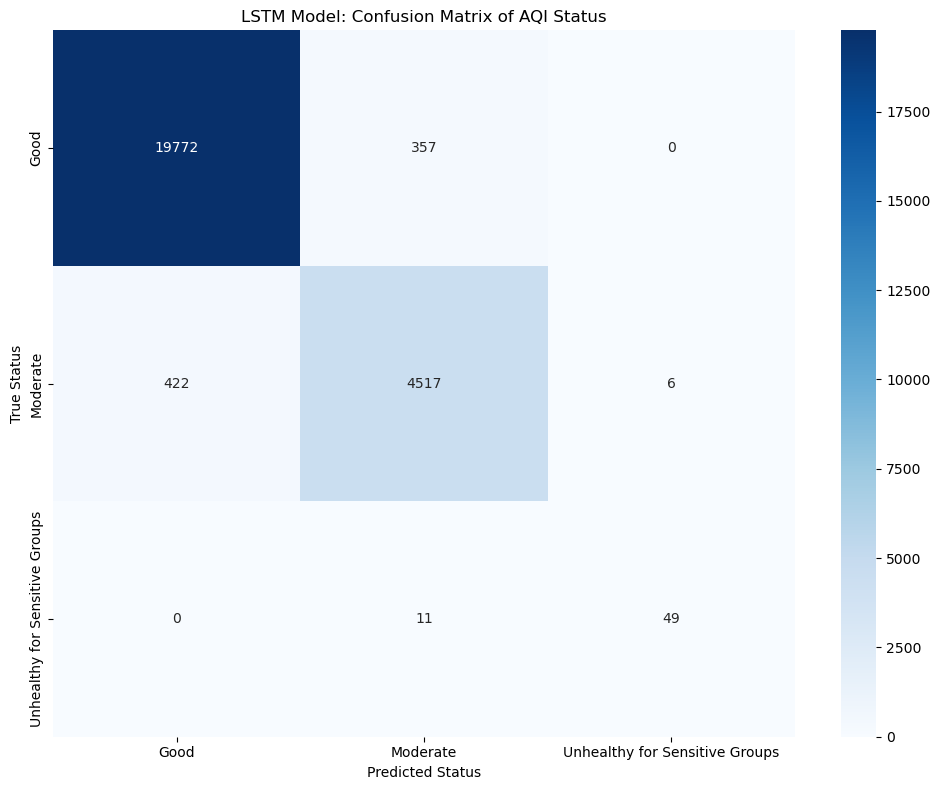

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import accuracy_score, precision_recall_fscore_support




# 1. Define a function to map the unscaled AQI values to their official status categories
def aqi_to_status(aqi_value):
    if aqi_value <= 50:
        return 'Good'
    elif aqi_value <= 100:
        return 'Moderate'
    elif aqi_value <= 150:
        return 'Unhealthy for Sensitive Groups'
    elif aqi_value <= 200:
        return 'Unhealthy'
    elif aqi_value <= 300:
        return 'Very Unhealthy'
    else:
        return 'Hazardous'

# 2. Convert continuous predicted AQI values into status labels
pred_statuses = [aqi_to_status(val) for val in predictions_all]

# 3. Extract the exact true status labels for the test set from the original dataframe
y_test_status_all = []
for station, group in df.groupby('sitename'):
    group = group.sort_values('date')
    train_len = int(np.ceil(len(group) * 0.80))
    # Collect chronological status strings for the 20% test partition
    for i in range(train_len, len(group)):
        y_test_status_all.append(group.iloc[i]['status'])

# 4. Define chronological order for categories to display logically in the matrix
all_possible_labels = ['Good', 'Moderate', 'Unhealthy for Sensitive Groups', 'Unhealthy', 'Very Unhealthy', 'Hazardous']
# Keep only labels that actually appear in the test dataset to avoid empty columns/rows
ordered_labels = [label for label in all_possible_labels if (label in y_test_status_all or label in pred_statuses)]

# 5. Compute the confusion matrix and print precision, recall, and F1-score
cm = confusion_matrix(y_test_status_all, pred_statuses, labels=ordered_labels)

print("--- Classification Report ---")
print(classification_report(y_test_status_all, pred_statuses, labels=ordered_labels))

# 6. Plot and save the Confusion Matrix as a Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=ordered_labels, yticklabels=ordered_labels)
plt.xlabel('Predicted Status')
plt.ylabel('True Status')
plt.title('LSTM Model: Confusion Matrix of AQI Status')
plt.tight_layout()
plt.savefig('LSTM_confusion_matrix.png')
plt.show()

In [35]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

# 1. Map the true unscaled continuous AQI values to their string status categories
y_test_status_ground_truth = [aqi_to_status(val) for val in y_test_all]

# 2. Calculate the classification metrics using both categorical string lists
accuracy = accuracy_score(y_test_status_ground_truth, pred_statuses)

precision, recall, f1, _ = precision_recall_fscore_support(
    y_test_status_ground_truth, 
    pred_statuses,              # Fixed: changed from predictions_all to pred_statuses
    average='weighted'
)

print("--- Overall Categorical Performance (Global) ---")
print(f"Accuracy:  {accuracy:.2%}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")

--- Overall Categorical Performance (Global) ---
Accuracy:  96.83%
Precision: 0.9682
Recall:    0.9683
F1-Score:  0.9682


In [30]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.optimizers import Adam
import keras_tuner as kt

# ==========================================
# 1. DEFINE THE HYPERMODEL BUILDER
# ==========================================
def build_lstm_hypermodel(hp):
    """
    Builds a flexible, searchable Stacked LSTM architecture.
    Supposes input shapes generated from your sliding window pipeline.
    """
    model = keras.models.Sequential()
    
    # We dynamically retrieve these values matching your processed array shapes
    # (e.g., timesteps=24, features=9)
    input_shape = (24, 9) 
    model.add(keras.layers.Input(shape=input_shape))

    # --- TUNE LAYER 1 LSTM ---
    hp_lstm_1_units = hp.Int('lstm_1_units', min_value=32, max_value=128, step=32)
    model.add(keras.layers.LSTM(units=hp_lstm_1_units, return_sequences=True))
    
    hp_dropout_1 = hp.Float('dropout_1', min_value=0.1, max_value=0.4, step=0.1)
    model.add(keras.layers.Dropout(rate=hp_dropout_1))
    
    # --- TUNE LAYER 2 LSTM ---
    hp_lstm_2_units = hp.Int('lstm_2_units', min_value=16, max_value=64, step=16)
    model.add(keras.layers.LSTM(units=hp_lstm_2_units, return_sequences=False))
    
    hp_dropout_2 = hp.Float('dropout_2', min_value=0.1, max_value=0.3, step=0.1)
    model.add(keras.layers.Dropout(rate=hp_dropout_2))
    
    # --- TUNE INTERMEDIATE DENSE LAYERS ---
    hp_dense_units = hp.Int('dense_units', min_value=16, max_value=64, step=16)
    model.add(keras.layers.Dense(units=hp_dense_units, activation='relu'))
    
    # --- OUTPUT REGRESSION LAYER ---
    model.add(keras.layers.Dense(1)) 

    # --- TUNE LEARNING RATE ---
    hp_learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])
    
    model.compile(
        optimizer=Adam(learning_rate=hp_learning_rate),
        loss='mae',  # Robust against outliers common in air quality indexes
        metrics=['mae', 'mse']
    )
    
    return model

# ==========================================
# 2. INITIALIZE THE TUNER EXECUTOR
# ==========================================
tuner = kt.RandomSearch(
    hypermodel=build_lstm_hypermodel,
    objective='val_loss',             # Minimize validation loss to clear flatlining
    max_trials=30,                    # Total configurations to test
    executions_per_trial=1,           # Trains each config once to save compute time
    directory='tuning_results_dir',   # Directory where logs are recorded
    project_name='taiwan_aqi_lstm',
    overwrite=True                    # Clear old logs if restarting the search space
)

# Early stopping callback ensures we do not waste computations on stalling configurations
stop_early = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', 
    patience=4, 
    restore_best_weights=True
)

# ==========================================
# 3. RUN THE SEARCH SPACE EXPLORATION
# ==========================================
# Assumes X_train, y_train have been correctly built via your station loops
tuner.search(
    X_train, y_train,
    epochs=20,
    batch_size=128,
    validation_split=0.2,
    callbacks=[stop_early],
    verbose=1
)

# ==========================================
# 4. EXTRACT AND EVALUATE RESULTS
# ==========================================
# Fetch the absolute best set of parameter choices found
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print("\n--- Hyperparameter Tuning Completed ---")
print(f"Optimal LSTM Layer 1 Units: {best_hps.get('lstm_1_units')}")
print(f"Optimal Dropout Layer 1   : {best_hps.get('dropout_1'):.2f}")
print(f"Optimal LSTM Layer 2 Units: {best_hps.get('lstm_2_units')}")
print(f"Optimal Dense Layer Units : {best_hps.get('dense_units')}")
print(f"Optimal Initial Learning Rate: {best_hps.get('learning_rate')}")

# Instantiate the final production model structure using the winning configuration
tuned_model = tuner.hypermodel.build(best_hps)

Trial 24 Complete [00h 13m 05s]
val_loss: 0.010546838864684105

Best val_loss So Far: 0.01023896038532257
Total elapsed time: 07h 09m 36s

Search: Running Trial #25

Value             |Best Value So Far |Hyperparameter
128               |64                |lstm_1_units
0.4               |0.2               |dropout_1
16                |48                |lstm_2_units
0.2               |0.1               |dropout_2
48                |16                |dense_units
0.01              |0.001             |learning_rate

Epoch 1/20
577/577 ━━━━━━━━━━━━━━━━━━━━ 125s 211ms/step - loss: 0.0233 - mae: 0.0233 - mse: 0.0015 - val_loss: 0.0133 - val_mae: 0.0133 - val_mse: 4.3739e-04
Epoch 2/20
577/577 ━━━━━━━━━━━━━━━━━━━━ 121s 211ms/step - loss: 0.0160 - mae: 0.0160 - mse: 5.5088e-04 - val_loss: 0.0123 - val_mae: 0.0123 - val_mse: 3.8705e-04
Epoch 3/20
577/577 ━━━━━━━━━━━━━━━━━━━━ 131s 227ms/step - loss: 0.0142 - mae: 0.0142 - mse: 4.5867e-04 - val_loss: 0.0148 - val_mae: 0.0148 - val_mse: 4.4987e-0

KeyboardInterrupt: 

In [31]:
tuned_model.fit(X_train, y_train, epochs=50, batch_size=128, shuffle=True,verbose=1,callbacks=my_callbacks,validation_data=(X_test_all, y_test_all))

Epoch 1/50
721/721 ━━━━━━━━━━━━━━━━━━━━ 75s 99ms/step - loss: 0.0247 - mae: 0.0247 - mse: 0.0015 - val_loss: 0.0157 - val_mae: 0.0157 - val_mse: 7.2260e-04 - learning_rate: 0.0010
Epoch 2/50
721/721 ━━━━━━━━━━━━━━━━━━━━ 76s 106ms/step - loss: 0.0146 - mae: 0.0146 - mse: 5.5686e-04 - val_loss: 0.0157 - val_mae: 0.0157 - val_mse: 7.0750e-04 - learning_rate: 0.0010
Epoch 3/50
721/721 ━━━━━━━━━━━━━━━━━━━━ 74s 102ms/step - loss: 0.0136 - mae: 0.0136 - mse: 4.8497e-04 - val_loss: 0.0153 - val_mae: 0.0153 - val_mse: 7.0131e-04 - learning_rate: 0.0010
Epoch 4/50
721/721 ━━━━━━━━━━━━━━━━━━━━ 73s 102ms/step - loss: 0.0130 - mae: 0.0130 - mse: 4.3815e-04 - val_loss: 0.0138 - val_mae: 0.0138 - val_mse: 5.5466e-04 - learning_rate: 0.0010
Epoch 5/50
721/721 ━━━━━━━━━━━━━━━━━━━━ 75s 104ms/step - loss: 0.0125 - mae: 0.0125 - mse: 4.0247e-04 - val_loss: 0.0125 - val_mae: 0.0125 - val_mse: 4.0880e-04 - learning_rate: 0.0010
Epoch 6/50
721/721 ━━━━━━━━━━━━━━━━━━━━ 81s 112ms/step - loss: 0.0120 - mae: 0.0

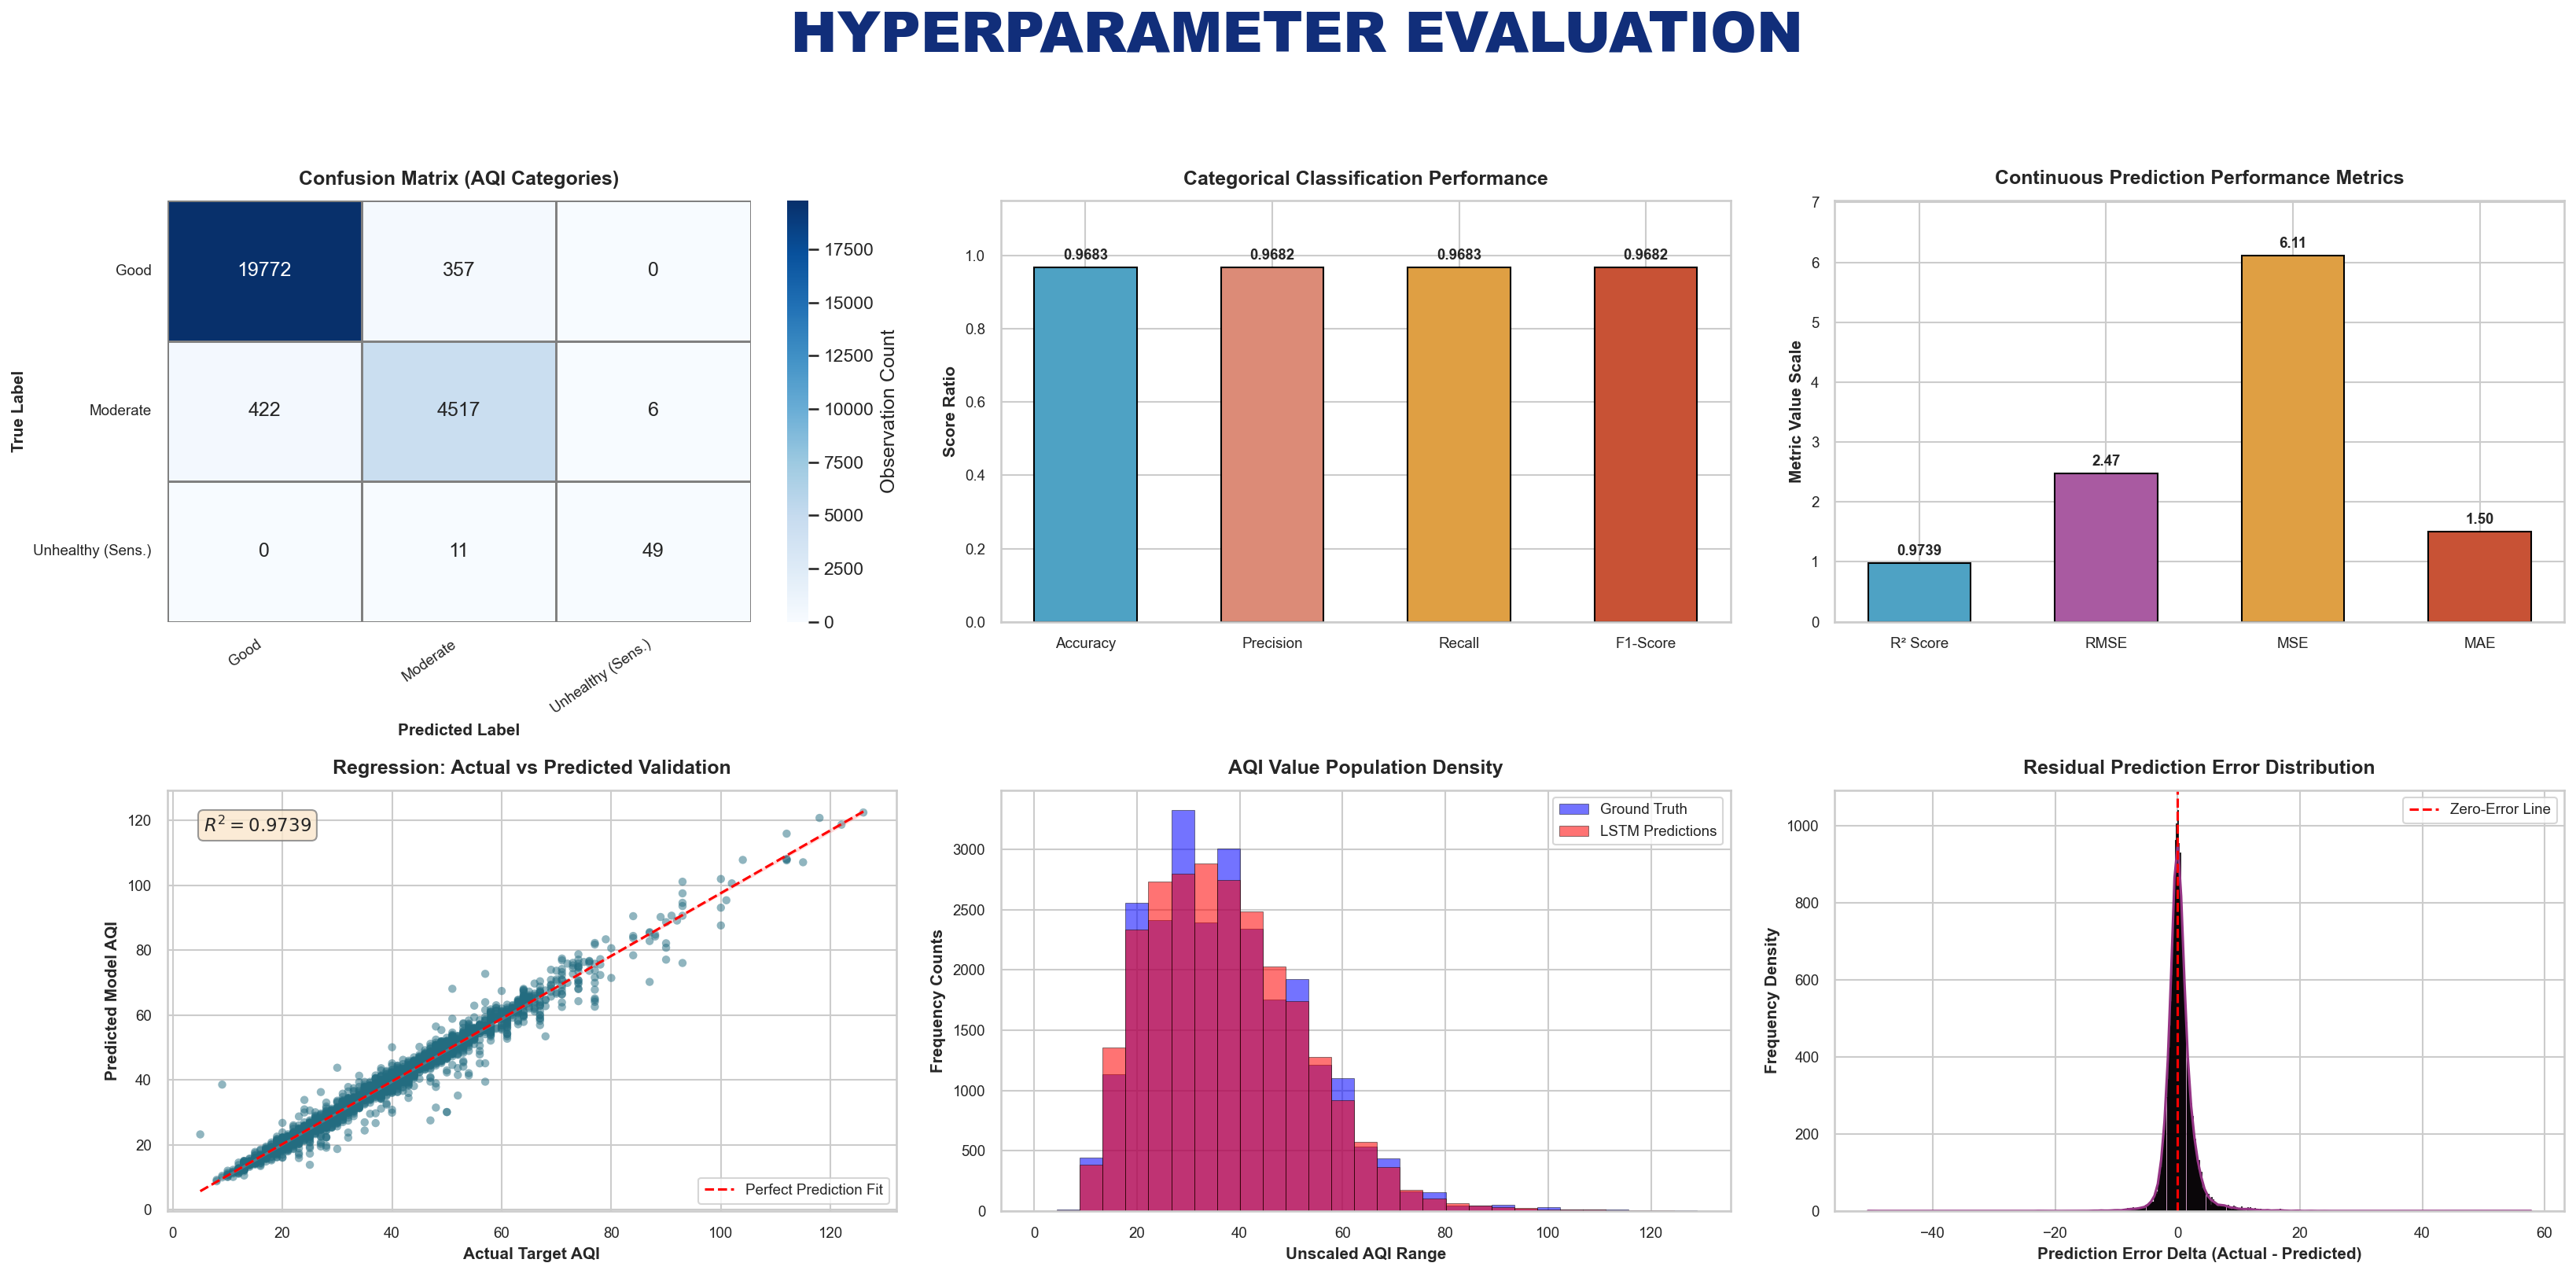

In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score, 
    recall_score, f1_score, r2_score, mean_squared_error, mean_absolute_error
)

# ==============================================================================
# 1. OFFICIAL AQI CATEGORICAL BREAKDOWN LOGIC
# ==============================================================================
def categorize_aqi(aqi):
    if aqi <= 50:    return "Good"
    elif aqi <= 100:  return "Moderate"
    elif aqi <= 150:  return "Unhealthy (Sens.)"
    elif aqi <= 200:  return "Unhealthy"
    elif aqi <= 300:  return "Very Unhealthy"
    else:             return "Hazardous"

# Ensure arrays are flattened 1D dimensions
y_true_flat = np.array(y_test_all).flatten()
y_pred_flat = np.array(predictions_all).flatten()

# Map continuous variables to categorical string targets
aqi_classes = ["Good", "Moderate", "Unhealthy (Sens.)", "Unhealthy", "Very Unhealthy", "Hazardous"]
y_true_cat = [categorize_aqi(x) for x in y_true_flat]
y_pred_cat = [categorize_aqi(x) for x in y_pred_flat]

# Filter down categories that actively appear in the target subset to avoid empty rows
active_labels = [label for label in aqi_classes if (label in y_true_cat or label in y_pred_cat)]

# ==============================================================================
# 2. METRICS EVALUATION GENERATION
# ==============================================================================
# Classification calculations (Weighted to account for sample distribution imbalance)
acc = accuracy_score(y_true_cat, y_pred_cat)
prec = precision_score(y_true_cat, y_pred_cat, average='weighted', zero_division=0)
rec = recall_score(y_true_cat, y_pred_cat, average='weighted', zero_division=0)
f1 = f1_score(y_true_cat, y_pred_cat, average='weighted', zero_division=0)

# Continuous Regression calculations
r2 = r2_score(y_true_flat, y_pred_flat)
mse = mean_squared_error(y_true_flat, y_pred_flat)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_true_flat, y_pred_flat)

# Residual Error calculations
residuals = y_true_flat - y_pred_flat

# ==============================================================================
# 3. MATPLOTLIB MULTI-PANEL CANVAS CREATION (2x3 Grid topology)
# ==============================================================================
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 3, figsize=(22, 11), dpi=150)
fig.suptitle(" HYPERPARAMETER EVALUATION", fontsize=34, fontweight="black", color="#112e7a", y=0.98)
plt.subplots_adjust(hspace=0.32, wspace=0.25)

# --- PANEL 1: CONFUSION MATRIX (Top Left) ---
ax = axes[0, 0]
cm = confusion_matrix(y_true_cat, y_pred_cat, labels=active_labels)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=True, ax=ax,
            xticklabels=active_labels, yticklabels=active_labels,
            linewidths=0.5, linecolor='gray', cbar_kws={'label': 'Observation Count'})
ax.set_title("Confusion Matrix (AQI Categories)", fontsize=12, fontweight="bold", pad=10)
ax.set_xlabel("Predicted Label", fontsize=10, fontweight="bold")
ax.set_ylabel("True Label", fontsize=10, fontweight="bold")
ax.set_xticklabels(active_labels, rotation=35, ha="right", fontsize=9)
ax.set_yticklabels(active_labels, rotation=0, fontsize=9)

# --- PANEL 2: CLASSIFICATION METRICS (Top Middle) ---
ax = axes[0, 1]
class_metrics = [acc, prec, rec, f1]
class_labels = ["Accuracy", "Precision", "Recall", "F1-Score"]
colors_class = ["#4ea2c4", "#dc8b77", "#df9f43", "#c85235"]

bars = ax.bar(class_labels, class_metrics, color=colors_class, edgecolor="black", width=0.55)
ax.set_title("Categorical Classification Performance", fontsize=12, fontweight="bold", pad=10)
ax.set_ylabel("Score Ratio", fontsize=10, fontweight="bold")
ax.set_ylim(0, 1.15)
ax.tick_params(labelsize=9)
for bar in bars:
    height = bar.get_height()
    ax.annotate(f"{height:.4f}", (bar.get_x() + bar.get_width()/2, height),
                ha='center', va='bottom', fontsize=9, fontweight="bold", xytext=(0, 3), textcoords="offset points")

# --- PANEL 3: REGRESSION METRICS (Top Right) ---
ax = axes[0, 2]
reg_metrics = [r2, rmse, mse, mae]
reg_labels = ["R² Score", "RMSE", "MSE", "MAE"]
colors_reg = ["#4ea2c4", "#a95aa1", "#df9f43", "#c85235"]

bars = ax.bar(reg_labels, reg_metrics, color=colors_reg, edgecolor="black", width=0.55)
ax.set_title("Continuous Prediction Performance Metrics", fontsize=12, fontweight="bold", pad=10)
ax.set_ylabel("Metric Value Scale", fontsize=10, fontweight="bold")
ax.set_ylim(0, max(reg_metrics) * 1.15 if max(reg_metrics) > 1 else 1.15)
ax.tick_params(labelsize=9)
for bar in bars:
    height = bar.get_height()
    fmt = f"{height:.4f}" if height < 1 else f"{height:.2f}"
    ax.annotate(fmt, (bar.get_x() + bar.get_width()/2, height),
                ha='center', va='bottom', fontsize=9, fontweight="bold", xytext=(0, 3), textcoords="offset points")

# --- PANEL 4: REGRESSION: ACTUAL VS PREDICTED (Bottom Left) ---
ax = axes[1, 0]
# Use a subset of points for the scatter plot to preserve speed and clarity
sample_idx = np.random.choice(len(y_true_flat), min(len(y_true_flat), 3000), replace=False)
sns.regplot(x=y_true_flat[sample_idx], y=y_pred_flat[sample_idx], ax=ax, color="#236c80",
            scatter_kws={"alpha": 0.5, "edgecolor": "none", "s": 25},
            line_kws={"color": "red", "linestyle": "--", "linewidth": 1.5, "label": "Perfect Prediction Fit"})
ax.set_title("Regression: Actual vs Predicted Validation", fontsize=12, fontweight="bold", pad=10)
ax.set_xlabel("Actual Target AQI", fontsize=10, fontweight="bold")
ax.set_ylabel("Predicted Model AQI", fontsize=10, fontweight="bold")
ax.tick_params(labelsize=9)
ax.text(0.05, 0.90, f"$R^2 = {r2:.4f}$", transform=ax.transAxes, fontsize=11,
        fontweight="bold", bbox=dict(boxstyle="round,pad=0.3", facecolor="#fae7cc", edgecolor="gray", alpha=0.8))
ax.legend(loc="lower right", fontsize=9)

# --- PANEL 5: SCORE DISTRIBUTION (Bottom Middle) ---
ax = axes[1, 1]
bins = np.linspace(0, max(y_true_flat), 30)
ax.hist(y_true_flat, bins=bins, alpha=0.55, color="blue", label="Ground Truth", edgecolor="black", linewidth=0.4)
ax.hist(y_pred_flat, bins=bins, alpha=0.55, color="red", label="LSTM Predictions", edgecolor="black", linewidth=0.4)
ax.set_title("AQI Value Population Density", fontsize=12, fontweight="bold", pad=10)
ax.set_xlabel("Unscaled AQI Range", fontsize=10, fontweight="bold")
ax.set_ylabel("Frequency Counts", fontsize=10, fontweight="bold")
ax.tick_params(labelsize=9)
ax.legend(loc="upper right", fontsize=9)

# --- PANEL 6: PREDICTION ERROR DISTRIBUTION (Bottom Right) ---
ax = axes[1, 2]
sns.histplot(residuals, kde=True, ax=ax, color="#953585", edgecolor="black", linewidth=0.4)
ax.axvline(x=0, color="red", linestyle="--", linewidth=1.5, label="Zero-Error Line")
ax.set_title("Residual Prediction Error Distribution", fontsize=12, fontweight="bold", pad=10)
ax.set_xlabel("Prediction Error Delta (Actual - Predicted)", fontsize=10, fontweight="bold")
ax.set_ylabel("Frequency Density", fontsize=10, fontweight="bold")
ax.tick_params(labelsize=9)
ax.legend(loc="upper right", fontsize=9)

# Save high-resolution visualization dashboard asset
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig("AQI_LSTM_tuning_dashboard.png", dpi=300, bbox_inches='tight')
plt.show()